<img src="https://www.metu.edu.tr/system/files/logo_orj/5/5.4.jpg" width="400" alt="Weights & Biases" />

# <font color='RED'>**📄 Surface Roughness Prediction In Additive Manufacturing**</font>

# Introduction

This notebook contains the machine learning workflow based only on the experimental dataset. It includes preprocessing, model development, and evaluation of the MLP model trained exclusively on real data.

Key Parameters:

The study focuses on 8 key printing parameters as model inputs ($X$): Layer Height, Extrusion Temperature, Outer Wall Speed, Infill Density, Wall Thickness, Bed Temperature, Fan Speed, and Surface Angle. The target output ($Y$) is the $R_a$ value.

## Please try installing the environment as described in the Readme file. If you want to run the code with your own Python environment, please ensure that the following libraries are installed.

In [ ]:
# pip install matplotlib numpy optuna pandas scikit-learn scipy shap tensorflow

# MLP Hyperparameter Tuning

In [1]:
import os, random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from pathlib import Path

# =============================================================================
# 1) CONFIGURATION
# =============================================================================
SEED = 42
TEST_SIZE = 0.15

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# =============================================================================
# 2) DATA LOADING
# =============================================================================
DATA_PATH = Path("..") / "dataset" / "mahr_data.csv"
df = pd.read_csv(DATA_PATH)

# Objects 85, 86, and 87 correspond to identical Box-Behnken center-point settings.
# To avoid repeated center-point samples in the analysis, only Object-85 is retained.
df = df[~df["ID"].isin(["Object-86", "Object-87"])].copy()

input_cols = [
    "Layer Height (mm)", "Extrusion Temp (°C)", "Outer Wall Speed (mm/s)",
    "Infill Density (%)", "Wall Thickness (mm)", "Bed Temp (°C)",
    "Fan Speed (%)", "Surface Angle (°)"
]
target_col = "Ra"

df_model = df[input_cols + [target_col]].dropna().reset_index(drop=True)

X_raw = df_model[input_cols].to_numpy(dtype=np.float32)
y_raw = df_model[target_col].to_numpy(dtype=np.float32).reshape(-1, 1)

print(f"Total samples (after dropna): {X_raw.shape[0]} | Features: {X_raw.shape[1]}")

# =============================================================================
# 3) HOLD-OUT TEST SPLIT: 85/15
# =============================================================================
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_raw, y_raw,
    test_size=TEST_SIZE,
    random_state=SEED,
    shuffle=True
)

print("\nHold-out split summary:")
print(f"Train/Val: {len(X_trainval)} ({len(X_trainval)/len(X_raw)*100:.1f}%)")
print(f"Test     : {len(X_test)} ({len(X_test)/len(X_raw)*100:.1f}%)")

Total samples (after dropna): 1530 | Features: 8

Hold-out split summary:
Train/Val: 1300 (85.0%)
Test     : 230 (15.0%)


[I 2026-01-18 21:12:35,959] A new study created in memory with name: no-name-27b3bec5-2665-4396-b19b-00d9cc2b1223


Seed: 42
TensorFlow: 2.20.0
Train/Val samples: 1300 | Test samples: 230 | Features: 8

Starting Optuna tuning with 5-fold CV (objective = mean CV MAE)...
TIMEOUT: 10.0 hours | N_TRIALS: 150 | FOLDS: 5


[I 2026-01-18 21:15:59,963] Trial 0 finished with value: 3.874000072479248 and parameters: {'n_layers': 3, 'units_l0': 384, 'units_l1': 288, 'units_l2': 256, 'dropout': 0.05, 'activation': 'ELU', 'lr': 0.0005, 'l2_reg': 1e-05, 'batch_size': 32}. Best is trial 0 with value: 3.874000072479248.
[I 2026-01-18 21:18:38,787] Trial 1 finished with value: 5.5771989822387695 and parameters: {'n_layers': 4, 'units_l0': 320, 'units_l1': 96, 'units_l2': 224, 'units_l3': 256, 'dropout': 0.0, 'activation': 'GELU', 'lr': 0.0001, 'l2_reg': 0.0001, 'batch_size': 32}. Best is trial 0 with value: 3.874000072479248.
[I 2026-01-18 21:21:18,685] Trial 2 finished with value: 3.728041172027588 and parameters: {'n_layers': 2, 'units_l0': 384, 'units_l1': 320, 'dropout': 0.3, 'activation': 'ELU', 'lr': 0.005, 'l2_reg': 0.0005, 'batch_size': 64}. Best is trial 2 with value: 3.728041172027588.
[I 2026-01-18 21:24:27,676] Trial 3 finished with value: 8.143779373168945 and parameters: {'n_layers': 2, 'units_l0': 32


Optimization finished.
Elapsed time: 573.8 minutes
Best CV MAE: 2.2133 μm
Best params:
  - n_layers: 5
  - units_l0: 64
  - units_l1: 32
  - units_l2: 224
  - units_l3: 352
  - units_l4: 224
  - dropout: 0.3
  - activation: LeakyReLU
  - lr: 0.005
  - l2_reg: 0.0
  - batch_size: 64

Best trial CV summary (reported):
  CV MSE : 12.022853
  CV R2  : 0.824013
  CV MAPE: 12.539 %
  Median best epoch (0-indexed): 116

FINAL TEST RESULTS (hold-out test)
MSE  : 10.737492
MAE  : 2.1996 μm
R2   : 0.8443
MAPE : 14.19 %
Refit epochs (suggested from CV): 117


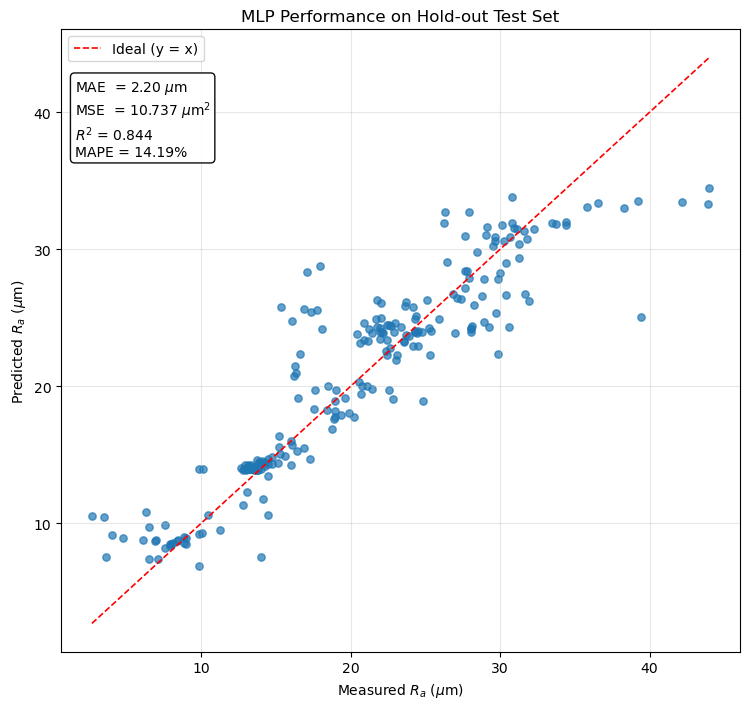

In [ ]:
import os, random, time, gc
import numpy as np
import tensorflow as tf
import optuna

from tensorflow.keras import layers, models, Input, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)
import matplotlib.pyplot as plt

# =============================================================================
# 1) CONFIG
# =============================================================================
SEED = 42
N_SPLITS = 5

TIMEOUT = 10 * 3600   # 10 hours
N_TRIALS = 150

MAX_EPOCHS_TUNING = 350
PATIENCE_ES = 25
PATIENCE_LR = 10

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print(f"Seed: {SEED}")
print(f"TensorFlow: {tf.__version__}")

# Sanity
assert "X_trainval" in globals() and "y_trainval" in globals(), "X_trainval / y_trainval not found."
assert "X_test" in globals() and "y_test" in globals(), "X_test / y_test not found."

X_trainval = np.asarray(X_trainval, dtype=np.float32)
y_trainval = np.asarray(y_trainval, dtype=np.float32).reshape(-1, 1)
X_test = np.asarray(X_test, dtype=np.float32)
y_test = np.asarray(y_test, dtype=np.float32).reshape(-1, 1)

INPUT_DIM = X_trainval.shape[1]
print(f"Train/Val samples: {len(X_trainval)} | Test samples: {len(X_test)} | Features: {INPUT_DIM}")

# =============================================================================
# 2) MODEL
# =============================================================================
def build_mlp(input_dim, n_layers, units_list, dropout, activation_name, l2_reg):
    x_in = Input(shape=(input_dim,), name="features")
    x = x_in

    for i in range(n_layers):
        x = layers.Dense(
            units_list[i],
            kernel_regularizer=regularizers.l2(l2_reg),
            name=f"dense_{i}"
        )(x)
        x = layers.BatchNormalization(name=f"bn_{i}")(x)

        if activation_name == "GELU":
            x = layers.Activation(tf.nn.gelu, name=f"gelu_{i}")(x)
        elif activation_name == "ELU":
            x = layers.ELU(name=f"elu_{i}")(x)
        elif activation_name == "LeakyReLU":
            x = layers.LeakyReLU(negative_slope=0.1, name=f"lrelu_{i}")(x)
        else:
            x = layers.ReLU(name=f"relu_{i}")(x)

        if dropout > 0:
            x = layers.Dropout(dropout, name=f"dropout_{i}")(x)

    y_out = layers.Dense(1, activation="linear", name="ra")(x)
    return models.Model(inputs=x_in, outputs=y_out, name="MLP_Regressor")

# =============================================================================
# 3) OPTUNA OBJECTIVE: 5-FOLD CV
# =============================================================================
def objective(trial):
    tf.keras.backend.clear_session()
    gc.collect()

    # Per-trial seed
    trial_seed = SEED + trial.number
    random.seed(trial_seed)
    np.random.seed(trial_seed)
    tf.random.set_seed(trial_seed)

    # Search space
    n_layers = trial.suggest_int("n_layers", 2, 6)
    units_list = [trial.suggest_int(f"units_l{i}", 32, 384, step=32) for i in range(n_layers)]

    dropout = trial.suggest_float("dropout", 0.0, 0.30, step=0.05)
    activation = trial.suggest_categorical("activation", ["ReLU", "LeakyReLU", "ELU", "GELU"])

    lr = trial.suggest_categorical("lr", [1e-4, 2e-4, 5e-4, 1e-3, 2e-3, 5e-3])
    l2_reg = trial.suggest_categorical("l2_reg", [0.0, 1e-6, 1e-5, 1e-4, 5e-4])
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128, 256])

    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    fold_mse, fold_mae, fold_r2, fold_mape = [], [], [], []
    fold_best_epochs = []

    for fold_idx, (tr_idx, va_idx) in enumerate(kf.split(X_trainval), start=1):
        X_tr, X_va = X_trainval[tr_idx], X_trainval[va_idx]
        y_tr, y_va = y_trainval[tr_idx], y_trainval[va_idx]

        scaler = MinMaxScaler()
        X_tr_sc = scaler.fit_transform(X_tr).astype(np.float32)
        X_va_sc = scaler.transform(X_va).astype(np.float32)

        tf.keras.backend.clear_session()
        model = build_mlp(
            input_dim=INPUT_DIM,
            n_layers=n_layers,
            units_list=units_list,
            dropout=dropout,
            activation_name=activation,
            l2_reg=l2_reg
        )

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0),
            loss=tf.keras.losses.MeanAbsoluteError(), 
            metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
        )

        callbacks = [
            EarlyStopping(monitor="val_mae", mode="min", patience=PATIENCE_ES,
                          restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor="val_mae", mode="min", factor=0.5,
                              patience=PATIENCE_LR, min_lr=1e-6, verbose=0),
        ]

        history = model.fit(
            X_tr_sc, y_tr,
            validation_data=(X_va_sc, y_va),
            epochs=MAX_EPOCHS_TUNING,
            batch_size=batch_size,
            verbose=0,
            shuffle=True,
            callbacks=callbacks
        )

        # Best epoch index for this fold (0-indexed)
        val_mae_curve = history.history.get("val_mae", [])
        if len(val_mae_curve) == 0:
            return float("inf")
        best_epoch = int(np.argmin(val_mae_curve))
        fold_best_epochs.append(best_epoch)

        # Predict & metrics on validation fold
        y_va_pred = model.predict(X_va_sc, verbose=0).reshape(-1, 1)

        mse = mean_squared_error(y_va, y_va_pred)
        mae = mean_absolute_error(y_va, y_va_pred)
        r2 = r2_score(y_va, y_va_pred)
        mape = mean_absolute_percentage_error(y_va, y_va_pred) * 100.0

        fold_mse.append(float(mse))
        fold_mae.append(float(mae))
        fold_r2.append(float(r2))
        fold_mape.append(float(mape))

        # Pruning at fold-level
        running_mean_mae = float(np.mean(fold_mae))
        trial.report(running_mean_mae, step=fold_idx)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    # Aggregate CV metrics
    mean_mse = float(np.mean(fold_mse))
    mean_mae = float(np.mean(fold_mae))
    mean_r2 = float(np.mean(fold_r2))
    mean_mape = float(np.mean(fold_mape))
    median_best_epoch = int(np.median(fold_best_epochs))

    # Store for later reporting / refit epoch suggestion
    trial.set_user_attr("cv_mean_mse", mean_mse)
    trial.set_user_attr("cv_mean_r2", mean_r2)
    trial.set_user_attr("cv_mean_mape", mean_mape)
    trial.set_user_attr("cv_median_best_epoch", median_best_epoch)

    return mean_mae

# =============================================================================
# 4) RUN OPTUNA
# =============================================================================
print("\nStarting Optuna tuning with 5-fold CV (objective = mean CV MAE)...")
print(f"TIMEOUT: {TIMEOUT/3600:.1f} hours | N_TRIALS: {N_TRIALS} | FOLDS: {N_SPLITS}")

t0 = time.time()
sampler = optuna.samplers.TPESampler(seed=SEED)
pruner = optuna.pruners.MedianPruner(n_warmup_steps=2)

study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=N_TRIALS, timeout=TIMEOUT, gc_after_trial=True)

elapsed = time.time() - t0

best = study.best_trial
print("\nOptimization finished.")
print(f"Elapsed time: {elapsed/60:.1f} minutes")
print(f"Best CV MAE: {study.best_value:.4f} μm")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  - {k}: {v}")

print("\nBest trial CV summary (reported):")
print(f"  CV MSE : {best.user_attrs.get('cv_mean_mse', None):.6f}")
print(f"  CV R2  : {best.user_attrs.get('cv_mean_r2', None):.6f}")
print(f"  CV MAPE: {best.user_attrs.get('cv_mean_mape', None):.3f} %")
print(f"  Median best epoch (0-indexed): {best.user_attrs.get('cv_median_best_epoch', None)}")

# =============================================================================
# 5) FINAL REFIT ON FULL TRAINVAL + TEST EVAL
# =============================================================================
bp = study.best_params
best_n_layers = bp["n_layers"]
best_units = [bp[f"units_l{i}"] for i in range(best_n_layers)]

scaler_final = MinMaxScaler()
X_trainval_sc = scaler_final.fit_transform(X_trainval).astype(np.float32)
X_test_sc = scaler_final.transform(X_test).astype(np.float32)

median_best_epoch = int(best.user_attrs.get("cv_median_best_epoch", 50))
final_epochs = int(median_best_epoch + 1)  
final_epochs = max(50, min(final_epochs, MAX_EPOCHS_TUNING)) 

tf.keras.backend.clear_session()
gc.collect()

final_model = build_mlp(
    input_dim=INPUT_DIM,
    n_layers=best_n_layers,
    units_list=best_units,
    dropout=bp["dropout"],
    activation_name=bp["activation"],
    l2_reg=bp["l2_reg"]
)

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=bp["lr"], clipnorm=1.0),
    loss=tf.keras.losses.MeanAbsoluteError(),
    metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
)

final_model.fit(
    X_trainval_sc, y_trainval,
    epochs=final_epochs,
    batch_size=bp["batch_size"],
    verbose=0,
    shuffle=True
)

y_test_pred = final_model.predict(X_test_sc, verbose=0).reshape(-1, 1)

test_mse = mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred) * 100.0

print("\nFINAL TEST RESULTS (hold-out test)")
print(f"MSE  : {test_mse:.6f}")
print(f"MAE  : {test_mae:.4f} μm")
print(f"R2   : {test_r2:.4f}")
print(f"MAPE : {test_mape:.2f} %")
print(f"Refit epochs (suggested from CV): {final_epochs}")

# =============================================================================
# 6) PLOT: MEASURED vs PREDICTED (TEST)
# =============================================================================
plt.figure(figsize=(7.6, 7.2))

y_true = y_test.reshape(-1) if hasattr(y_test, 'reshape') else np.array(y_test).flatten()
y_pred = y_test_pred.reshape(-1) if hasattr(y_test_pred, 'reshape') else np.array(y_test_pred).flatten()

plt.scatter(y_true, y_pred, alpha=0.70, s=28)

min_val = float(min(y_true.min(), y_pred.min()))
max_val = float(max(y_true.max(), y_pred.max()))
plt.plot([min_val, max_val], [min_val, max_val], "r--", lw=1.2, label="Ideal (y = x)")

plt.xlabel(r"Measured $R_a$ ($\mu$m)")
plt.ylabel(r"Predicted $R_a$ ($\mu$m)")
plt.title("MLP Performance on Hold-out Test Set")

metrics_text = (
    f"MAE  = {test_mae:.2f} " + r"$\mu$m" + "\n"
    f"MSE  = {test_mse:.3f} " + r"$\mu$m$^2$" + "\n" 
    f"$R^2$ = {test_r2:.3f}\n"
    f"MAPE = {test_mape:.2f}%"
)

plt.text(
    0.02, 0.92, metrics_text,
    transform=plt.gca().transAxes,
    va="top", ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.95),
    fontsize=10  
)

plt.grid(True, alpha=0.30)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()